In [25]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
import pandas as pd

In [32]:
def merge(left, right):
    merged = []
    i = j = 0
    
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1
            
    merged.extend(left[i:])
    merged.extend(right[j:])
    
    return merged


def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    
    mid = len(arr) // 2
    left_half = merge_sort(arr[:mid])
    right_half = merge_sort(arr[mid:])
    
    return merge(left_half, right_half)


# Test
arr = [random.randint(1, 1000) for _ in range(100)]
start = time.perf_counter()
sorted_arr = merge_sort(arr)
end = time.perf_counter()

print("Sorted (first 10):", sorted_arr[:10])
print("Time Taken:", round(end - start, 6), "seconds")

Sorted (first 10): [24, 25, 52, 61, 86, 118, 123, 131, 136, 143]
Time Taken: 0.000302 seconds


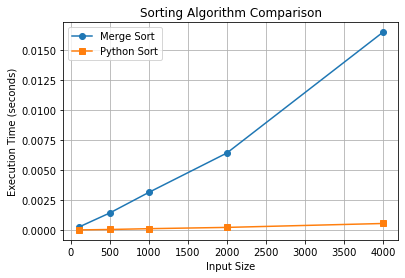

In [27]:
sizes = [100, 500, 1000, 2000, 4000]

merge_times = []
builtin_times = []

for size in sizes:
    data = [random.randint(1, 10000) for _ in range(size)]
    
    # Merge Sort timing
    start = time.perf_counter()
    merge_sort(data.copy())
    merge_times.append(time.perf_counter() - start)
    
    # Built-in sort timing
    start = time.perf_counter()
    sorted(data)
    builtin_times.append(time.perf_counter() - start)


plt.figure()
plt.plot(sizes, merge_times, marker='o', label="Merge Sort")
plt.plot(sizes, builtin_times, marker='s', label="Python Sort")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Sorting Algorithm Comparison")
plt.legend()
plt.grid()
plt.show()

In [28]:
def activity_selection(start, finish):
    activities = list(zip(start, finish))
    
    # Sort by finish time
    activities.sort(key=lambda x: x[1])
    
    selected = [activities[0]]
    
    for i in range(1, len(activities)):
        if activities[i][0] >= selected[-1][1]:
            selected.append(activities[i])
    
    return selected


start = [1, 3, 0, 5, 8, 5]
finish = [2, 4, 6, 7, 9, 9]

result = activity_selection(start, finish)

print("Selected Activities (start, end):")
for act in result:
    print(act)

Selected Activities (start, end):
(1, 2)
(3, 4)
(5, 7)
(8, 9)


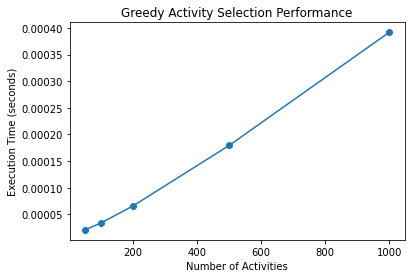

In [29]:
# ------------------ GRAPH PERFORMANCE TEST ------------------

# Different input sizes
sizes = [50, 100, 200, 500, 1000]

execution_times = []   # Store execution times

for size in sizes:
    
    # Generate random start times
    start = [random.randint(0, 10000) for _ in range(size)]
    
    # Generate finish times (ensure finish > start)
    finish = [start[i] + random.randint(1, 100) for i in range(size)]
    
    # Measure execution time
    start_time = time.perf_counter()
    activity_selection(start, finish)
    execution_times.append(time.perf_counter() - start_time)


# ------------------ PLOT GRAPH ------------------

plt.figure()

plt.plot(sizes, execution_times, marker='o')

plt.xlabel("Number of Activities")
plt.ylabel("Execution Time (seconds)")
plt.title("Greedy Activity Selection Performance")

plt.show()

In [30]:
def knapsack_dp(weights, values, capacity):
    n = len(values)
    dp = [[0] * (capacity + 1) for _ in range(n + 1)]
    
    for i in range(1, n + 1):
        for w in range(capacity + 1):
            if weights[i-1] <= w:
                dp[i][w] = max(
                    values[i-1] + dp[i-1][w - weights[i-1]],
                    dp[i-1][w]
                )
            else:
                dp[i][w] = dp[i-1][w]
    
    return dp[n][capacity]


values = [60, 100, 120]
weights = [10, 20, 30]
capacity = 50

start = time.perf_counter()
result = knapsack_dp(weights, values, capacity)
end = time.perf_counter()

print("Maximum Value:", result)
print("Execution Time:", round(end - start, 6), "seconds")

Maximum Value: 220
Execution Time: 0.000112 seconds


In [31]:
def tsp_bruteforce(graph):
    n = len(graph)
    nodes = list(range(n))
    
    min_cost = float('inf')
    best_path = None
    
    for perm in permutations(nodes[1:]):
        current_cost = 0
        k = 0
        
        for j in perm:
            current_cost += graph[k][j]
            k = j
        
        current_cost += graph[k][0]
        
        if current_cost < min_cost:
            min_cost = current_cost
            best_path = (0,) + perm + (0,)
    
    return min_cost, best_path


graph = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]

start = time.perf_counter()
cost, path = tsp_bruteforce(graph)
end = time.perf_counter()

print("Minimum Cost:", cost)
print("Best Path:", path)
print("Execution Time:", round(end - start, 6), "seconds")

Minimum Cost: 80
Best Path: (0, 1, 3, 2, 0)
Execution Time: 6.3e-05 seconds


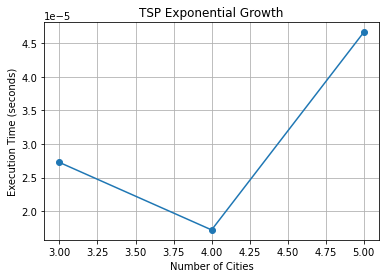

In [24]:
sizes = [3, 4, 5]
times = []

for n in sizes:
    graph = np.random.randint(1, 50, size=(n, n))
    np.fill_diagonal(graph, 0)
    
    start = time.perf_counter()
    tsp_bruteforce(graph)
    times.append(time.perf_counter() - start)

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Number of Cities")
plt.ylabel("Execution Time (seconds)")
plt.title("TSP Exponential Growth")
plt.grid()
plt.show()

In [33]:
import pandas as pd

data = {
    "Algorithm": ["Merge Sort", "Activity Selection", "Knapsack", "TSP"],
    "Technique": ["Divide & Conquer", "Greedy", "Dynamic Programming", "Brute Force"],
    "Complexity": ["O(n log n)", "O(n log n)", "O(nW)", "O(n!)"],
    "Use Case": ["Sorting", "Scheduling", "Optimization", "Routing"]
}

df = pd.DataFrame(data)
print(df)

            Algorithm            Technique  Complexity      Use Case
0          Merge Sort     Divide & Conquer  O(n log n)       Sorting
1  Activity Selection               Greedy  O(n log n)    Scheduling
2            Knapsack  Dynamic Programming       O(nW)  Optimization
3                 TSP          Brute Force       O(n!)       Routing


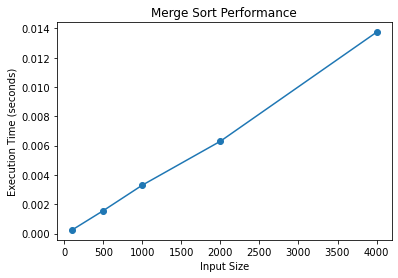

In [34]:
def merge(left, right):
    merged = []
    i = j = 0
    
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1
    
    merged.extend(left[i:])
    merged.extend(right[j:])
    
    return merged


def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    
    mid = len(arr) // 2
    
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    
    return merge(left, right)


# ------------------ PERFORMANCE TEST ------------------

sizes = [100, 500, 1000, 2000, 4000]
times = []

for size in sizes:
    
    # Generate random list
    data = [random.randint(1, 10000) for _ in range(size)]
    
    # Measure time
    start = time.perf_counter()
    merge_sort(data)
    end = time.perf_counter()
    
    times.append(end - start)


# ------------------ PLOT GRAPH ------------------

plt.figure()

plt.plot(sizes, times, marker='o')

plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Merge Sort Performance")

plt.show()